In [1]:
!pip install sklearn-genetic sklearn-genetic-opt

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, auc, roc_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from sklearn_genetic import GAFeatureSelectionCV

import joblib

2026-04-08 10:47:20.928789: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775645241.326220      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775645241.438624      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775645242.380589      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775645242.380642      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775645242.380645      24 computation_placer.cc:177] computation placer alr

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
data_dir = "/kaggle/input/datasets/ajaymaddi07/updated-dataset"

filepaths = []
labels = []

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    for file in os.listdir(class_path):
        filepaths.append(os.path.join(class_path, file))
        labels.append(label)

df = pd.DataFrame({
    "filename": filepaths,
    "class": labels
})

df.head()

,filename,class
0,/kaggle/input/datasets/ajaymaddi07/updated-dat...,Normal
1,/kaggle/input/datasets/ajaymaddi07/updated-dat...,Normal
2,/kaggle/input/datasets/ajaymaddi07/updated-dat...,Normal
3,/kaggle/input/datasets/ajaymaddi07/updated-dat...,Normal
4,/kaggle/input/datasets/ajaymaddi07/updated-dat...,Normal


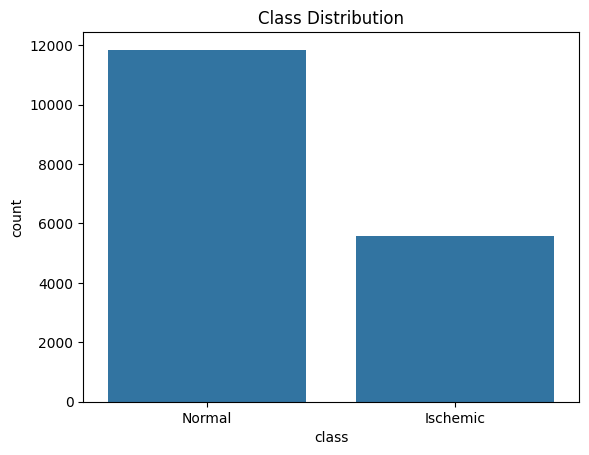

In [5]:
sns.countplot(x=df['class'])
plt.title("Class Distribution")
plt.show()

In [6]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['class'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['class'], random_state=42)

In [7]:
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(train_df, x_col='filename', y_col='class',
                                        target_size=img_size, class_mode='binary', batch_size=batch_size)

val_gen = datagen.flow_from_dataframe(val_df, x_col='filename', y_col='class',
                                      target_size=img_size, class_mode='binary', batch_size=batch_size)

test_gen = datagen.flow_from_dataframe(test_df, x_col='filename', y_col='class',
                                       target_size=img_size, class_mode='binary', batch_size=batch_size, shuffle=False)

Found 12199 validated image filenames belonging to 2 classes.
Found 2614 validated image filenames belonging to 2 classes.
Found 2615 validated image filenames belonging to 2 classes.


In [8]:
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = GlobalAveragePooling2D()(base_model.output)
feature_model = Model(inputs=base_model.input, outputs=x)

I0000 00:00:1775645354.963073      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775645354.969189      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
def extract_features(model, generator):
    generator.reset()
    features = []
    labels = []
    steps = int(np.ceil(generator.samples / generator.batch_size))

    for i in range(steps):
        x_batch, y_batch = next(generator)
        feat = model.predict(x_batch, verbose=0)
        features.append(feat)
        labels.append(y_batch)

    return np.vstack(features), np.hstack(labels)

In [10]:
X_train, y_train = extract_features(feature_model, train_gen)
X_val, y_val = extract_features(feature_model, val_gen)
X_test, y_test = extract_features(feature_model, test_gen)

I0000 00:00:1775645362.157797      78 service.cc:152] XLA service 0x7a41e4157c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775645362.157844      78 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775645362.157848      78 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775645363.532167      78 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775645370.432003      78 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [11]:
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)

class_weights = dict(zip(np.unique(y_train), class_weights))

In [12]:
ga = GAFeatureSelectionCV(
    estimator=SVC(kernel='rbf',class_weight=class_weights),
    cv=3,
    scoring="recall",
    population_size=15,
    generations=15,
    n_jobs=-1
)

In [13]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.90)),
    ("ga", ga)
])

In [14]:
X_train_opt = pipeline.fit_transform(X_train, y_train)
X_val_opt = pipeline.transform(X_val)
X_test_opt = pipeline.transform(X_test)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	15    	0.876969	0.00927616 	0.889507   	0.859228   
1  	30    	0.885566	0.00384315 	0.890712   	0.87672    
2  	30    	0.885976	0.0026402  	0.889506   	0.880701   
3  	30    	0.8837  	0.00354562 	0.889506   	0.877443   
4  	30    	0.885742	0.00244924 	0.891074   	0.88251    
5  	30    	0.881858	0.00713616 	0.891074   	0.866344   
6  	30    	0.886498	0.0033455  	0.891074   	0.879976   
7  	30    	0.887632	0.00308597 	0.89228    	0.879614   
8  	30    	0.889007	0.00142293 	0.89228    	0.885888   
9  	30    	0.889659	0.000835111	0.89228    	0.889144   
10 	30    	0.888356	0.00420835 	0.892884   	0.876478   
11 	30    	0.886192	0.00655921 	0.892884   	0.867793   
12 	30    	0.889659	0.00404872 	0.895537   	0.880821   
13 	30    	0.89068 	0.00491331 	0.895537   	0.87479    
14 	30    	0.887921	0.008869   	0.896743   	0.865862   
15 	30    	0.888139	0.00926589 	0.897347   	0.869844   


In [15]:
def reshape_for_lstm(X):
    return X.reshape(X.shape[0], 1, X.shape[1])

X_train_lstm = reshape_for_lstm(X_train_opt)
X_val_lstm = reshape_for_lstm(X_val_opt)
X_test_lstm = reshape_for_lstm(X_test_opt)

In [16]:
lstm_model = Sequential([
    LSTM(128, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6942 - loss: 0.5773 - val_accuracy: 0.8122 - val_loss: 0.4230
Epoch 2/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8449 - loss: 0.3630 - val_accuracy: 0.8424 - val_loss: 0.3808
Epoch 3/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8989 - loss: 0.2482 - val_accuracy: 0.8485 - val_loss: 0.3778
Epoch 4/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9366 - loss: 0.1612 - val_accuracy: 0.8542 - val_loss: 0.4260
Epoch 5/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9524 - loss: 0.1253 - val_accuracy: 0.8535 - val_loss: 0.4431
Epoch 6/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9686 - loss: 0.0840 - val_accuracy: 0.8539 - val_loss: 0.4612
Epoch 7/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9744 - loss: 0.0698 - val_accuracy: 0.8604 - val_loss: 0.4939
Epoch 8/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9801 - loss: 0.0539 - val_accuracy: 0.

In [19]:
loss, acc = lstm_model.evaluate(X_test_lstm, y_test)
print(f"Test Accuracy : {acc*100:.2f}")

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8685 - loss: 0.5801
Test Accuracy : 86.42


In [20]:
y_pred_proba = lstm_model.predict(X_test_lstm)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred))

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

         0.0       0.83      0.73      0.78       838
         1.0       0.88      0.93      0.90      1777

    accuracy                           0.86      2615
   macro avg       0.85      0.83      0.84      2615
weighted avg       0.86      0.86      0.86      2615



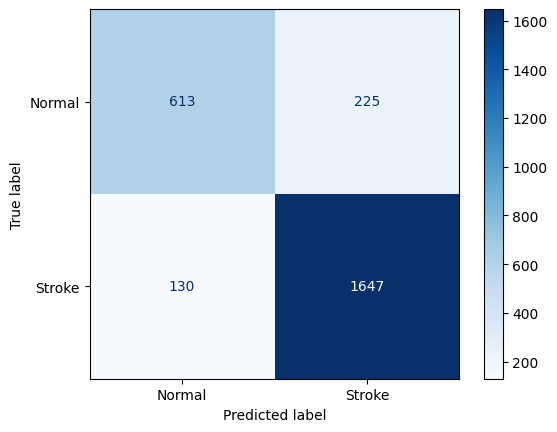

In [21]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Normal','Stroke']
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap="Blues")

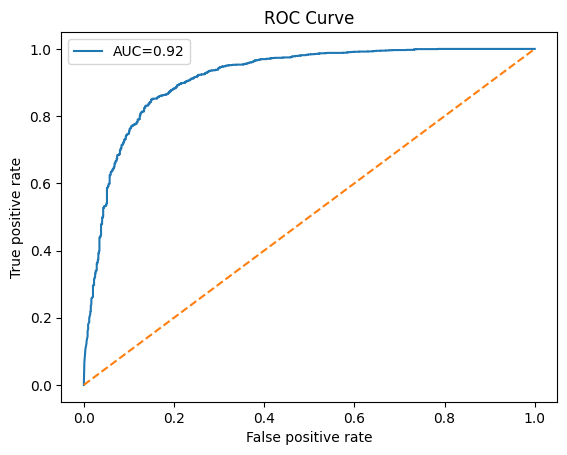

In [22]:
fpr,tpr, _ = roc_curve(y_test,y_pred_proba)
roc_auc = auc(fpr,tpr)

plt.figure()
plt.plot(fpr,tpr,label=f"AUC={roc_auc:.2f}")
plt.plot([0,1], [0,1],linestyle = '--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [23]:
lstm_model.save("/kaggle/working/lstm_final_model.keras")
feature_model.save("/kaggle/working/InceptionV3(lstm).keras")
joblib.dump(pipeline, "/kaggle/working/pipeline(lstm).pkl")

['/kaggle/working/pipeline(lstm).pkl']

In [24]:
lstm_model = keras.models.load_model("/kaggle/working/lstm_final_model.keras")
features_model = keras.models.load_model("/kaggle/working/InceptionV3(lstm).keras")
pipeline = joblib.load("/kaggle/working/pipeline(lstm).pkl")